In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Task

The dataset is at solutions/galaxyquasar.csv.

* Create arrays for the colors. Also create an array with the class labels where galaxy=0 and quasar=1.
* Classify the dataset against the target label.
* Try some of the classification methods we've seen so far and evaluate the performance using the ROC curve.
* Remember to split the dataset into training and validation...

Ideas
* Try using different colors (a subset of them first, than all together). Which is the most important feature?
* What are the colors that better satisfy or invalidate the "Naive" assumption of independence between the attributes?

## Preparing and investigating data

In [3]:
data = pd.read_csv('..\solutions\galaxyquasar.csv')

In [4]:
data

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [5]:
data['u-g']= data['u']-data['g']
data['g-r']= data['g']-data['r']
data['r-i']= data['r']-data['i']
data['i-z']= data['i']-data['z']

classes = np.loadtxt('..\solutions\galaxyquasar.csv', delimiter =',', usecols=5, dtype=str, skiprows=1)
index = np.where(classes=='QSO')
types = np.zeros(len(data['class'])).astype(int)
types[index]=1
data['type']= types

In [6]:
data

,u,g,r,i,z,class,z1,zerr,u-g,g-r,r-i,i-z,type
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155,0.43537,-0.04604,0.23344,0.05721,1
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028,1.76946,0.99829,0.43345,0.35621,0
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000,1.73268,0.78703,0.33238,0.19199,0
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009,1.13314,0.78721,0.45042,0.29154,0
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631,0.17640,0.22251,0.08924,0.30830,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011,1.24913,0.72496,0.41383,0.27918,0
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014,1.63759,0.84982,0.46396,0.34430,0
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008,1.31842,0.43505,0.24972,0.20103,0
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009,1.27429,0.65610,0.40154,0.18600,0


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt


color_cols = ['u-g', 'g-r', 'r-i', 'i-z']
data_red = data[['u-g', 'g-r', 'r-i', 'i-z', 'type']]

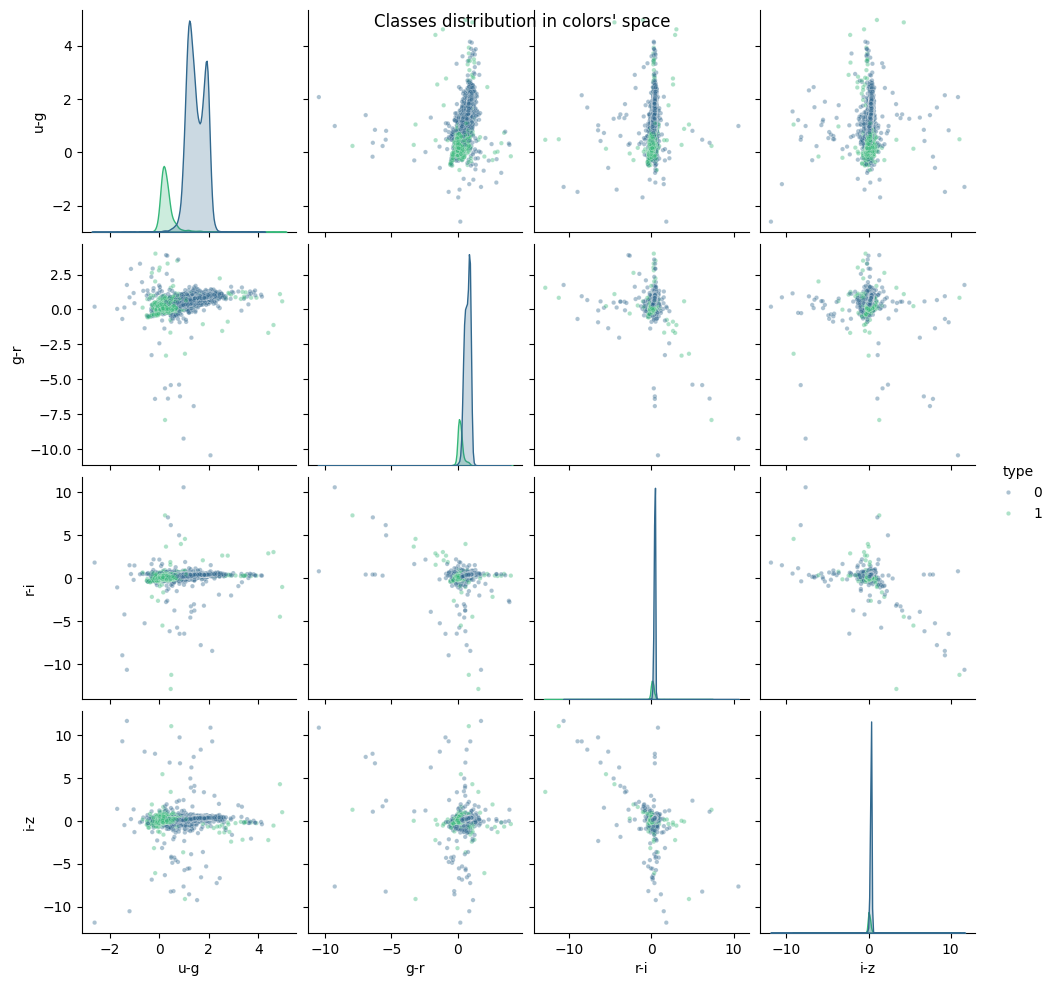

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt


color_cols = ['u-g', 'g-r', 'r-i', 'i-z']
data_red = data[['u-g', 'g-r', 'r-i', 'i-z', 'type']]

sns.pairplot(data_red, vars=color_cols, hue='type', 
             plot_kws={'alpha': 0.4, 's': 10}, palette='viridis')
plt.suptitle("Classes distribution in colors' space", y=1.02)
plt.show()

## Classification 

In [7]:
from sklearn.model_selection import KFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from astroML.classification import GMMBayes
from sklearn.neighbors import KNeighborsClassifier
from itertools import combinations

### Gaussian NB

In [8]:
X=np.array([data['u-g'], data['g-r'], data['r-i'], data['i-z']]).T

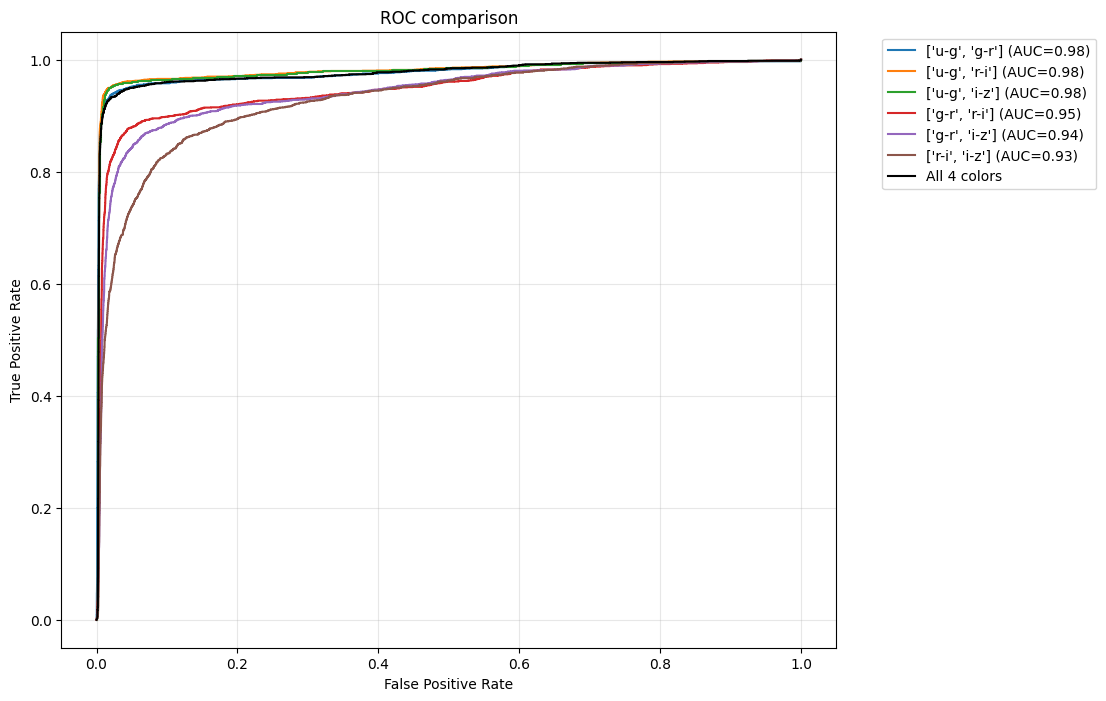

In [12]:
y = data['type'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

plt.figure(figsize=(10, 8))
colors_col_int = [0,1,2,3]
# Test of all combinations of 2 colors
for combo in combinations(colors_col_int, 2):
    combo_label= [color_cols[combo[0]], color_cols[combo[1]]]
    model = GaussianNB()
    model.fit(X_train[:,list(combo)], y_train)
    probs = model.predict_proba(X_test[:,list(combo)])[:, 1]
    fpr, tpr, trsh = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{combo_label} (AUC={auc(fpr, tpr):.2f})')#, alpha=0.6) #area below curve

# All 4 colours
model_all = GaussianNB()
model_all.fit(X_train, y_train)
probs_all = model_all.predict_proba(X_test)[:, 1]
fpr_all, tpr_all, _ = roc_curve(y_test, probs_all)
plt.plot(fpr_all, tpr_all, label='All 4 colors', color='black')#, alpha=0.3)


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC comparison')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.show()

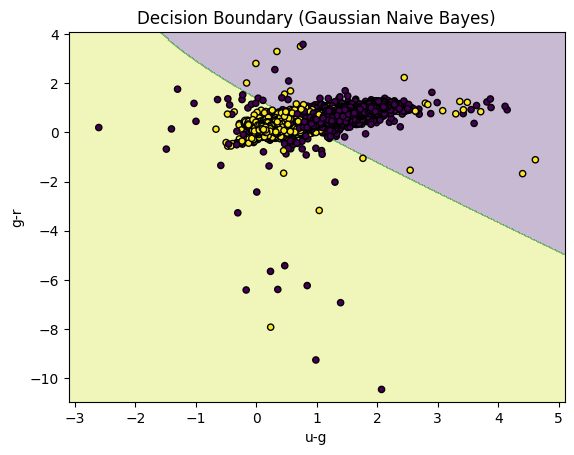

In [14]:
def plot_decision_boundaries(X, y, model, labels):
    h = .02  # step size in meshgrid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20, cmap='viridis')
    plt.xlabel(labels[0])
    plt.ylabel(labels[1])

# u-g and g-r
best_two = [0,1]
model_2d = GaussianNB().fit(X_train[:,best_two], y_train)
plot_decision_boundaries(X_train[:,best_two], y_train, model_2d, labels=['u-g', 'g-r'])
plt.title("Decision Boundary (Gaussian Naive Bayes)")
plt.show()

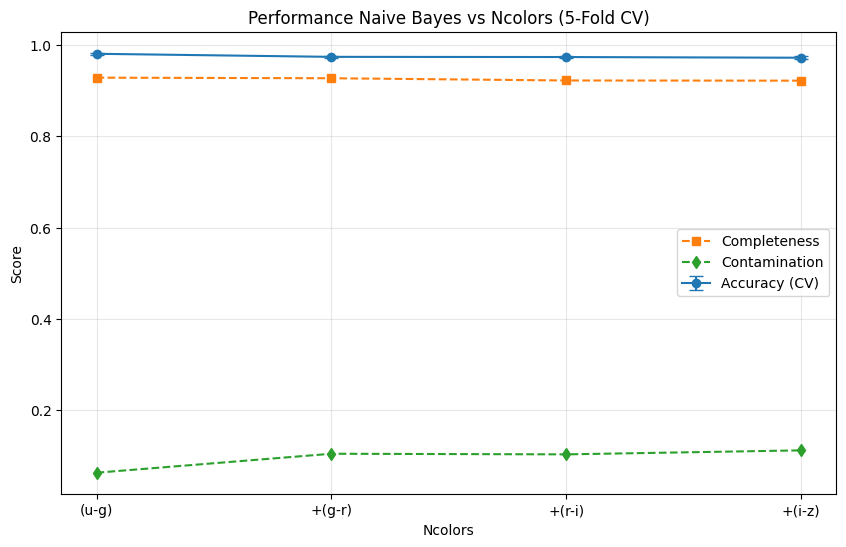

Best accuracy reached: 0.981


In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from astroML.utils import completeness_contamination
from sklearn.model_selection import cross_val_score

accuracies = []
accuracies_std = []
completeness_list = []
contamination_list = []


Ncolors = np.arange(1, X.shape[1] + 1) #(u-g), (g-r), (r-i), (i-z)

# Setup for Cross-Validation (Stratified keeps classes proportion)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nc in Ncolors:
    clf = GaussianNB()
    X_subset = X[:, :nc]
    
    # Accuracy for each folding
    scores = cross_val_score(clf, X_subset, y, cv=cv, scoring='accuracy')
    accuracies.append(scores.mean())
    accuracies_std.append(scores.std())
    
    # Completeness and Contamination prediction, using each point only when it is in the test set
    y_pred_cv = cross_val_predict(clf, X_subset, y, cv=cv)
    
    # metrics
    compl, contam = completeness_contamination(y_pred_cv, y)
    completeness_list.append(compl)
    contamination_list.append(contam)



plt.figure(figsize=(10, 6))

plt.errorbar(Ncolors, accuracies, yerr=accuracies_std, fmt='-o', capsize=5, label='Accuracy (CV)')

plt.plot(Ncolors, completeness_list, '--s', label='Completeness')
plt.plot(Ncolors, contamination_list, '--d', label='Contamination')

plt.xlabel('Ncolors')
plt.ylabel('Score')
plt.title('Performance Naive Bayes vs Ncolors (5-Fold CV)')
plt.xticks(Ncolors, ['(u-g)', '+(g-r)', '+(r-i)', '+(i-z)'])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Best accuracy reached: {max(accuracies):.3f}")

## Linear & Quadratic Discriminant Analysis

In [16]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA


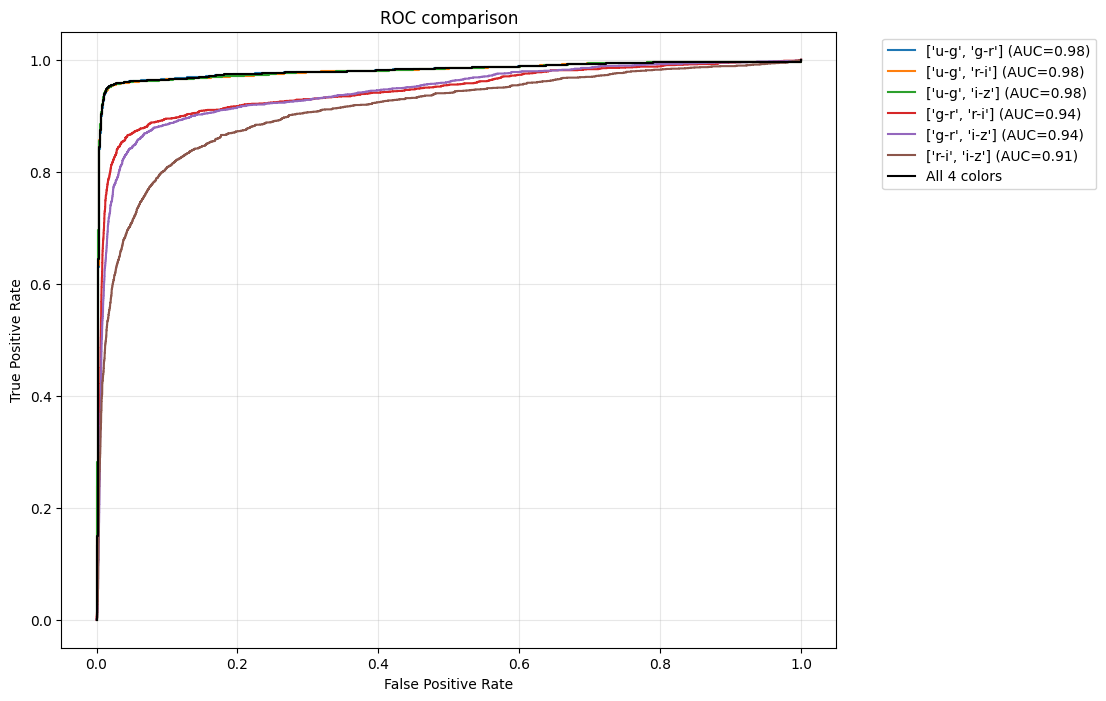

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

plt.figure(figsize=(10, 8))
colors_col_int = [0,1,2,3]
# Test of all combinations of 2 colors
for combo in combinations(colors_col_int, 2):
    combo_label= [color_cols[combo[0]], color_cols[combo[1]]]
    model = LDA()
    model.fit(X_train[:,list(combo)], y_train)
    probs = model.predict_proba(X_test[:,list(combo)])[:, 1]
    fpr, tpr, trsh = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{combo_label} (AUC={auc(fpr, tpr):.2f})')#, alpha=0.6) #area below curve

# All 4 colours
model_all = LDA()
model_all.fit(X_train, y_train)
probs_all = model_all.predict_proba(X_test)[:, 1]
fpr_all, tpr_all, _ = roc_curve(y_test, probs_all)
plt.plot(fpr_all, tpr_all, label='All 4 colors', color='black')#, alpha=0.3)


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC comparison')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.show()

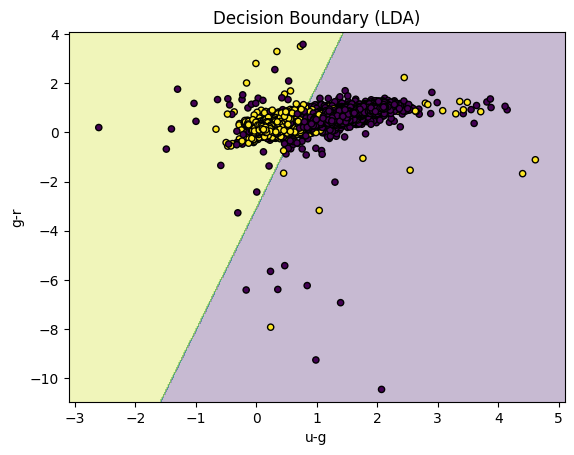

In [18]:
def plot_decision_boundaries(X, y, model, labels):
    h = .02  # step size in meshgrid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20, cmap='viridis')
    plt.xlabel(labels[0])
    plt.ylabel(labels[1])

# u-g and g-r
best_two = [0,1]
model_2d = LDA().fit(X_train[:,best_two], y_train)
plot_decision_boundaries(X_train[:,best_two], y_train, model_2d, labels=['u-g', 'g-r'])
plt.title("Decision Boundary (LDA)")
plt.show()

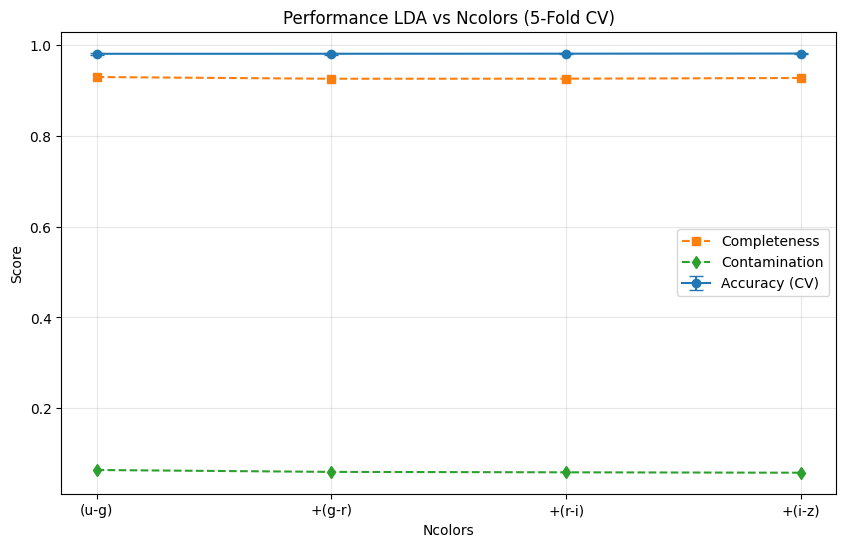

Best accuracy reached: 0.982


In [19]:
accuracies = []
accuracies_std = []
completeness_list = []
contamination_list = []


Ncolors = np.arange(1, X.shape[1] + 1) #(u-g), (g-r), (r-i), (i-z)

# Setup for Cross-Validation (Stratified keeps classes proportion)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nc in Ncolors:
    clf = LDA()
    X_subset = X[:, :nc]
    
    # Accuracy for each folding
    scores = cross_val_score(clf, X_subset, y, cv=cv, scoring='accuracy')
    accuracies.append(scores.mean())
    accuracies_std.append(scores.std())
    
    # Completeness and Contamination prediction, using each point only when it is in the test set
    y_pred_cv = cross_val_predict(clf, X_subset, y, cv=cv)
    
    # metrics
    compl, contam = completeness_contamination(y_pred_cv, y)
    completeness_list.append(compl)
    contamination_list.append(contam)



plt.figure(figsize=(10, 6))

plt.errorbar(Ncolors, accuracies, yerr=accuracies_std, fmt='-o', capsize=5, label='Accuracy (CV)')

plt.plot(Ncolors, completeness_list, '--s', label='Completeness')
plt.plot(Ncolors, contamination_list, '--d', label='Contamination')

plt.xlabel('Ncolors')
plt.ylabel('Score')
plt.title('Performance LDA vs Ncolors (5-Fold CV)')
plt.xticks(Ncolors, ['(u-g)', '+(g-r)', '+(r-i)', '+(i-z)'])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Best accuracy reached: {max(accuracies):.3f}")

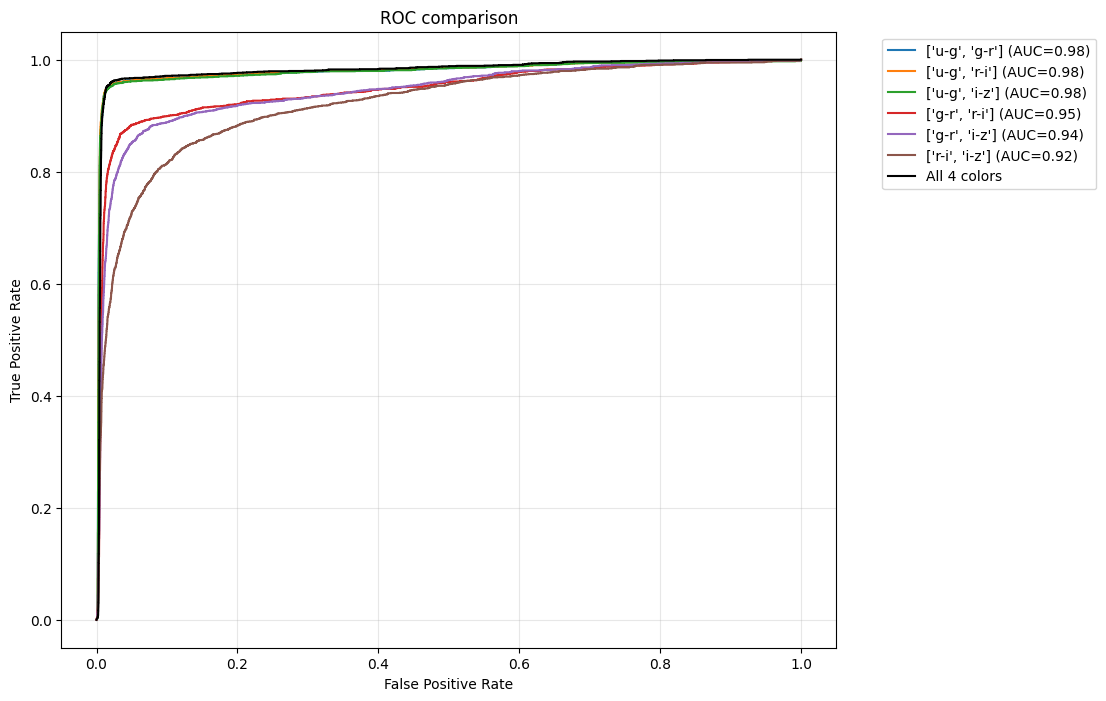

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

plt.figure(figsize=(10, 8))
colors_col_int = [0,1,2,3]
# Test of all combinations of 2 colors
for combo in combinations(colors_col_int, 2):
    combo_label= [color_cols[combo[0]], color_cols[combo[1]]]
    model = QDA()
    model.fit(X_train[:,list(combo)], y_train)
    probs = model.predict_proba(X_test[:,list(combo)])[:, 1]
    fpr, tpr, trsh = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{combo_label} (AUC={auc(fpr, tpr):.2f})')#, alpha=0.6) #area below curve

# All 4 colours
model_all = QDA()
model_all.fit(X_train, y_train)
probs_all = model_all.predict_proba(X_test)[:, 1]
fpr_all, tpr_all, _ = roc_curve(y_test, probs_all)
plt.plot(fpr_all, tpr_all, label='All 4 colors', color='black')#, alpha=0.3)


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC comparison')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.show()

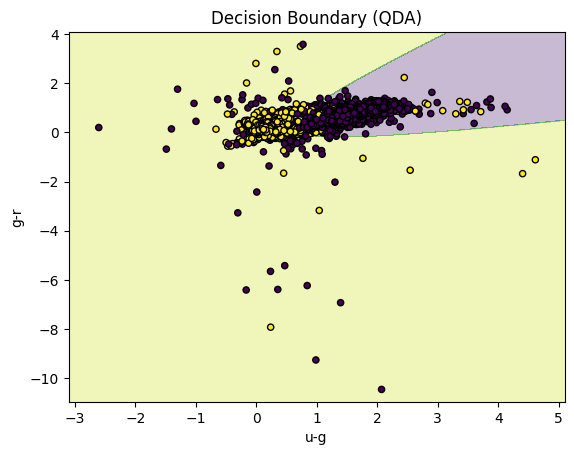

In [21]:
def plot_decision_boundaries(X, y, model, labels):
    h = .02  # step size in meshgrid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20, cmap='viridis')
    plt.xlabel(labels[0])
    plt.ylabel(labels[1])

# u-g and g-r
best_two = [0,1]
model_2d = QDA().fit(X_train[:,best_two], y_train)
plot_decision_boundaries(X_train[:,best_two], y_train, model_2d, labels=['u-g', 'g-r'])
plt.title("Decision Boundary (QDA)")
plt.show()

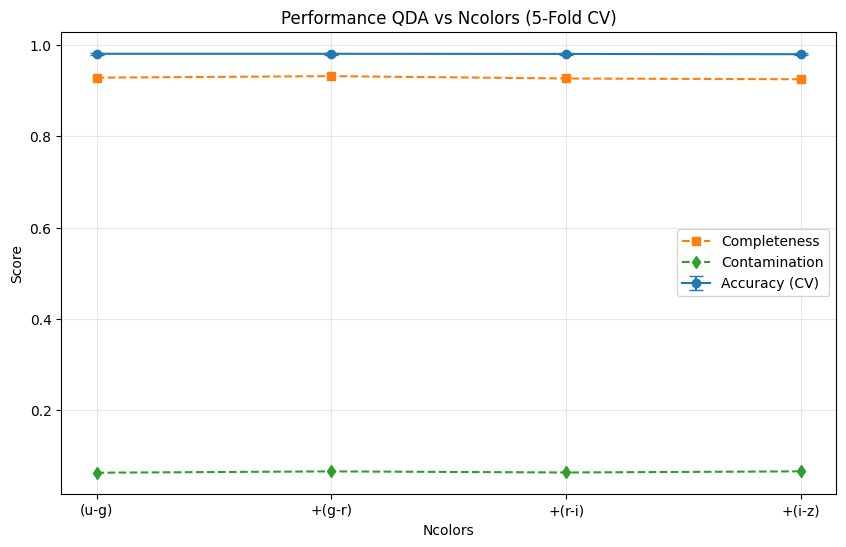

Best accuracy reached: 0.981


In [22]:
accuracies = []
accuracies_std = []
completeness_list = []
contamination_list = []


Ncolors = np.arange(1, X.shape[1] + 1) #(u-g), (g-r), (r-i), (i-z)

# Setup for Cross-Validation (Stratified keeps classes proportion)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nc in Ncolors:
    clf = QDA()
    X_subset = X[:, :nc]
    
    # Accuracy for each folding
    scores = cross_val_score(clf, X_subset, y, cv=cv, scoring='accuracy')
    accuracies.append(scores.mean())
    accuracies_std.append(scores.std())
    
    # Completeness and Contamination prediction, using each point only when it is in the test set
    y_pred_cv = cross_val_predict(clf, X_subset, y, cv=cv)
    
    # metrics
    compl, contam = completeness_contamination(y_pred_cv, y)
    completeness_list.append(compl)
    contamination_list.append(contam)



plt.figure(figsize=(10, 6))

plt.errorbar(Ncolors, accuracies, yerr=accuracies_std, fmt='-o', capsize=5, label='Accuracy (CV)')

plt.plot(Ncolors, completeness_list, '--s', label='Completeness')
plt.plot(Ncolors, contamination_list, '--d', label='Contamination')

plt.xlabel('Ncolors')
plt.ylabel('Score')
plt.title('Performance QDA vs Ncolors (5-Fold CV)')
plt.xticks(Ncolors, ['(u-g)', '+(g-r)', '+(r-i)', '+(i-z)'])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Best accuracy reached: {max(accuracies):.3f}")

## GMM Bayes

Optimal number of components is: 38


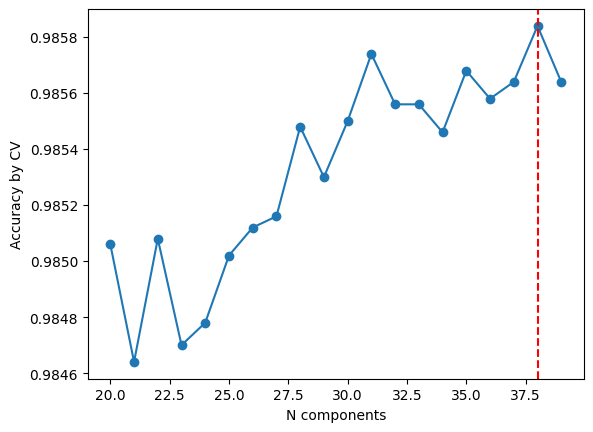

In [25]:

from sklearn.model_selection import cross_val_score, StratifiedKFold
from astroML.classification import GMMBayes 

n_components_range = np.arange(20, 40)
cv_scores = []

for n in n_components_range:
    # covariance_type='full' to see correlations (non-naive)
    clf = GMMBayes(n_components=n, covariance_type='full')
    scores = cross_val_score(clf, X, y, cv=5)
    cv_scores.append(scores.mean())

best_n = n_components_range[np.argmax(cv_scores)]
print(f"Optimal number of components is: {best_n}")

plt.plot(n_components_range, cv_scores, 'o-')
plt.axvline(best_n, color='red', linestyle='--')
plt.xlabel('N components')
plt.ylabel('Accuracy by CV')
plt.show()

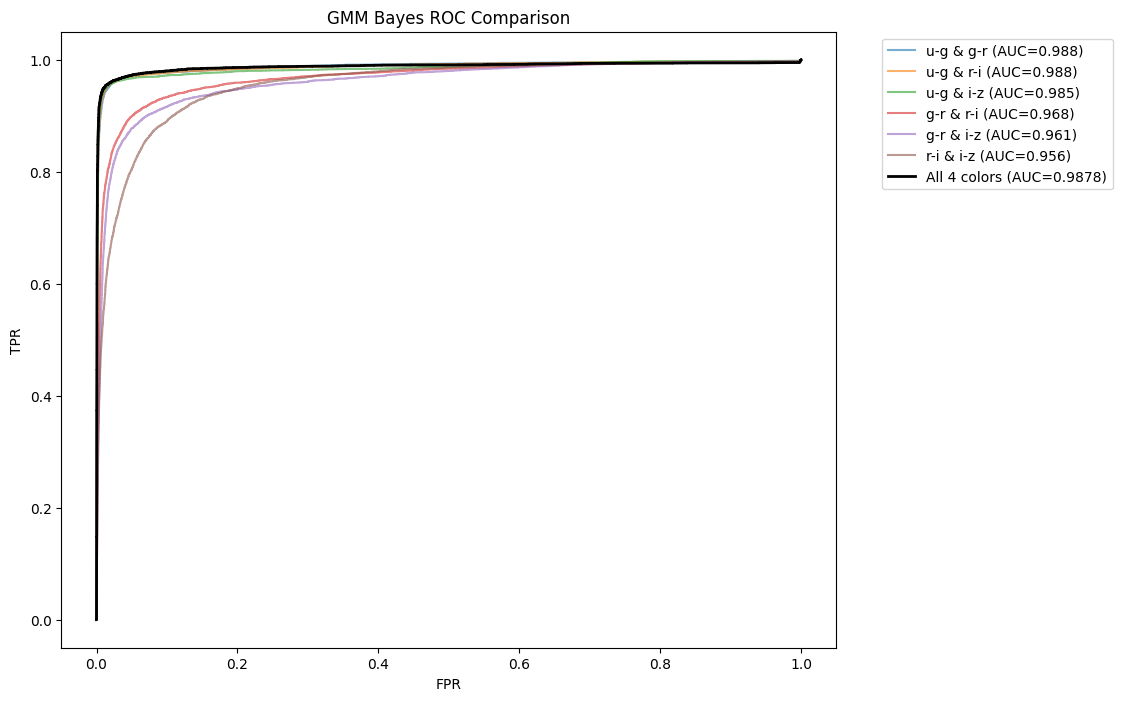

In [26]:
color_labels = ['u-g', 'g-r', 'r-i', 'i-z']
plt.figure(figsize=(10, 8))

# All combinations
for combo_idx in combinations(range(4), 2):
    clf = GMMBayes(n_components=best_n)
    # CV prob
    y_prob = cross_val_predict(clf, X[:, list(combo_idx)], y, cv=5, method='predict_proba')[:, 1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    
    label_name = f"{color_labels[combo_idx[0]]} & {color_labels[combo_idx[1]]}"
    plt.plot(fpr, tpr, label=f'{label_name} (AUC={auc(fpr, tpr):.3f})', alpha=0.6)

# Test su tutti i 4 colori
y_prob_all = cross_val_predict(GMMBayes(n_components=best_n), X, y, cv=5, method='predict_proba')[:, 1]
fpr_all, tpr_all, _ = roc_curve(y, y_prob_all)
plt.plot(fpr_all, tpr_all, color='black', lw=2, label=f'All 4 colors (AUC={auc(fpr_all, tpr_all):.4f})')


plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('GMM Bayes ROC Comparison')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

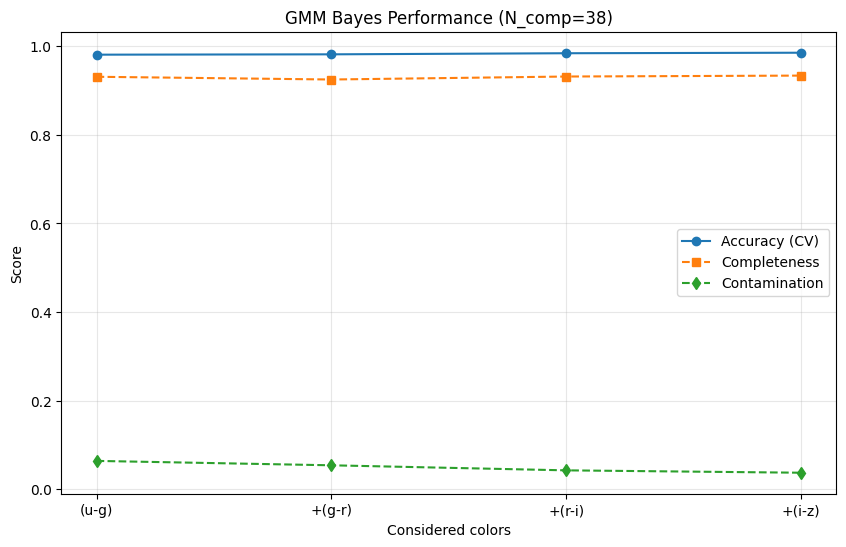

In [27]:

accuracies = []
completeness_list = []
contamination_list = []

Ncolors = np.arange(1, X.shape[1] + 1)

for nc in Ncolors:
    X_subset = X[:, :nc]
    
    clf = GMMBayes(n_components=best_n, covariance_type='full')
    
    # Accuracy
    acc = cross_val_score(clf, X_subset, y, cv=5).mean()
    accuracies.append(acc)
    
    # Completeness and Completeness prediction
    y_pred = cross_val_predict(clf, X_subset, y, cv=5)
    compl, contam = completeness_contamination(y_pred, y)
    completeness_list.append(compl)
    contamination_list.append(contam)

plt.figure(figsize=(10, 6))
plt.plot(Ncolors, accuracies, '-o', label='Accuracy (CV)')
plt.plot(Ncolors, completeness_list, '--s', label='Completeness')
plt.plot(Ncolors, contamination_list, '--d', label='Contamination')
plt.xticks(Ncolors, ['(u-g)', '+(g-r)', '+(r-i)', '+(i-z)'])
plt.xlabel('Considered colors')
plt.ylabel('Score')
plt.title(f'GMM Bayes Performance (N_comp={best_n})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [28]:
print(f"Best accuracy reached: {max(accuracies):.3f}")

Best accuracy reached: 0.985


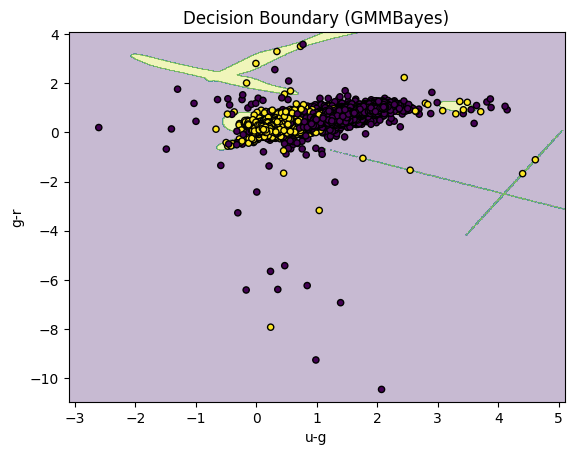

In [29]:
def plot_decision_boundaries(X, y, model, labels):
    h = .02  # step size in meshgrid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20, cmap='viridis')
    plt.xlabel(labels[0])
    plt.ylabel(labels[1])

# u-g and g-r
best_two = [0,1]
model_2d =GMMBayes(n_components=best_n, covariance_type='full').fit(X_train[:,best_two], y_train)
plot_decision_boundaries(X_train[:,best_two], y_train, model_2d, labels=['u-g', 'g-r'])
plt.title("Decision Boundary (GMMBayes)")
plt.show()

## KNeighbours

In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

Best k: 11


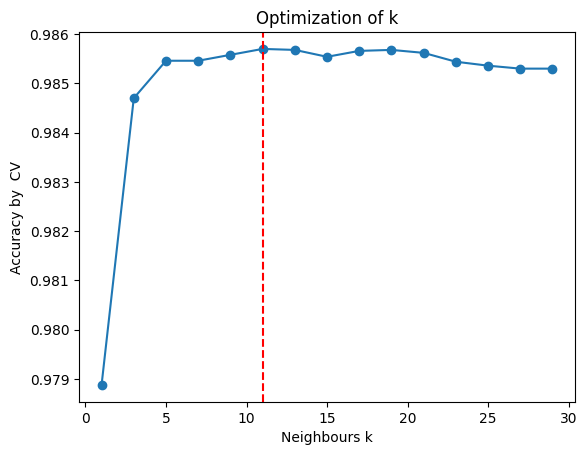

In [31]:
#CV on k number
k_neighbors = np.arange(1, 31, 2)
cv_scores = []

for k in k_neighbors:
    # found out that it's typical to use a pipeline to mesh together
    # scaler prepocessing and the model to avoid 'data leakage' in the CV splitting procedure
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    
    scores = cross_val_score(pipe, X, y, cv=5)
    cv_scores.append(scores.mean())

best_k = k_neighbors[np.argmax(cv_scores)]
print(f"Best k: {best_k}")

plt.plot(k_neighbors, cv_scores, 'o-')
plt.axvline(best_k, color='r', linestyle='--')
plt.xlabel('Neighbours k')
plt.ylabel('Accuracy by  CV')
plt.title('Optimization of k')
plt.show()

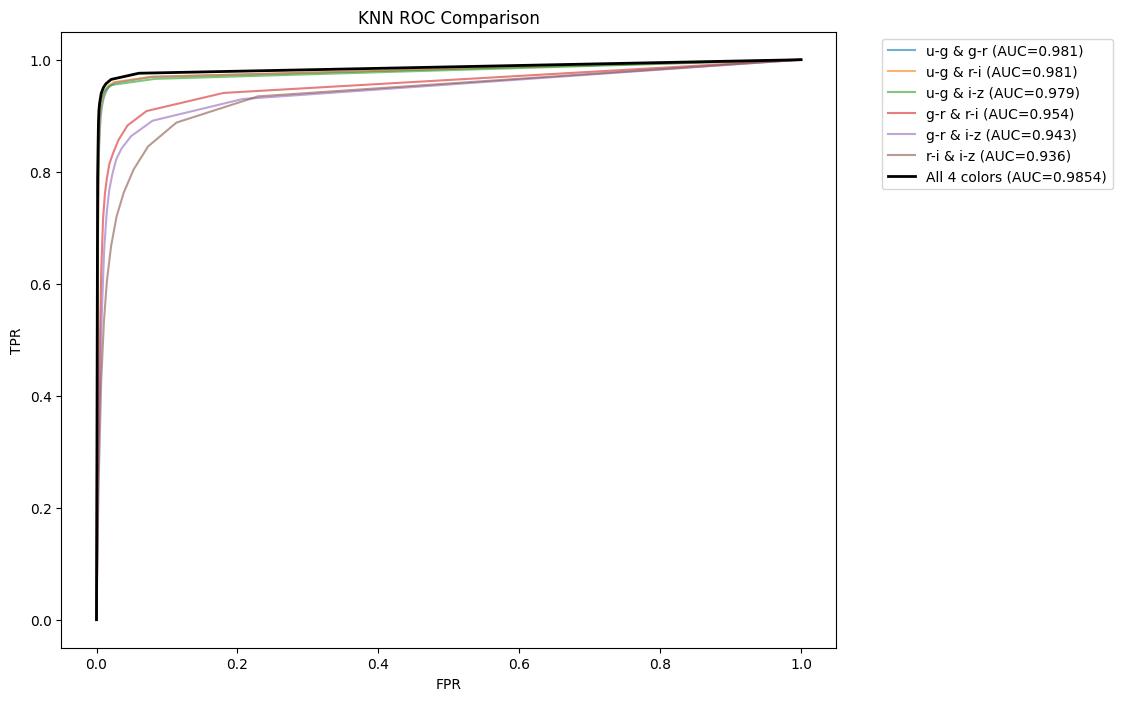

In [32]:
color_labels = ['u-g', 'g-r', 'r-i', 'i-z']
plt.figure(figsize=(10, 8))

# All combinations
for combo_idx in combinations(range(4), 2):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=best_k))
    ])
    # CV prob
    y_prob = cross_val_predict(pipe, X[:, list(combo_idx)], y, cv=5, method='predict_proba')[:, 1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    
    label_name = f"{color_labels[combo_idx[0]]} & {color_labels[combo_idx[1]]}"
    plt.plot(fpr, tpr, label=f'{label_name} (AUC={auc(fpr, tpr):.3f})', alpha=0.6)

# Test su tutti i 4 colori
pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=best_k))
    ])
y_prob_all = cross_val_predict(pipe, X, y, cv=5, method='predict_proba')[:, 1]
fpr_all, tpr_all, _ = roc_curve(y, y_prob_all)
plt.plot(fpr_all, tpr_all, color='black', lw=2, label=f'All 4 colors (AUC={auc(fpr_all, tpr_all):.4f})')


plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('KNN ROC Comparison')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

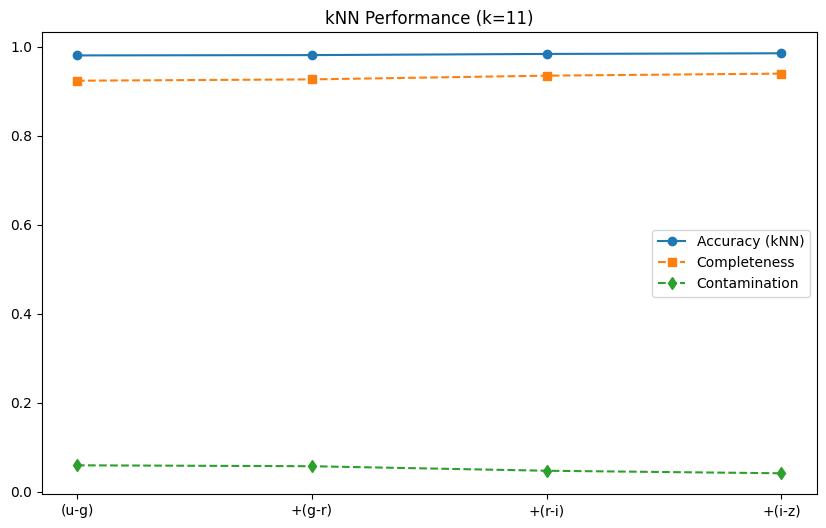

In [33]:
accuracies_knn = []
compl_knn = []
contam_knn = []


for nc in Ncolors:
    X_subset = X[:, :nc]
    
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=best_k))
    ])
    
    #Accuracy
    acc = cross_val_score(pipe, X_subset, y, cv=5).mean()
    accuracies_knn.append(acc)
    
    # Completeness and Contamination
    y_pred = cross_val_predict(pipe, X_subset, y, cv=5)
    compl, contam = completeness_contamination(y_pred, y)
    compl_knn.append(compl)
    contam_knn.append(contam)

# Plot dei risultati
plt.figure(figsize=(10, 6))
plt.plot(Ncolors, accuracies_knn, '-o', label='Accuracy (kNN)')
plt.plot(Ncolors, compl_knn, '--s', label='Completeness')
plt.plot(Ncolors, contam_knn, '--d', label='Contamination')
plt.xticks(Ncolors, ['(u-g)', '+(g-r)', '+(r-i)', '+(i-z)'])
plt.title(f'kNN Performance (k={best_k})')
plt.legend()
plt.show()

In [34]:
print(f"Best accuracy reached: {max(accuracies):.3f}")

Best accuracy reached: 0.985


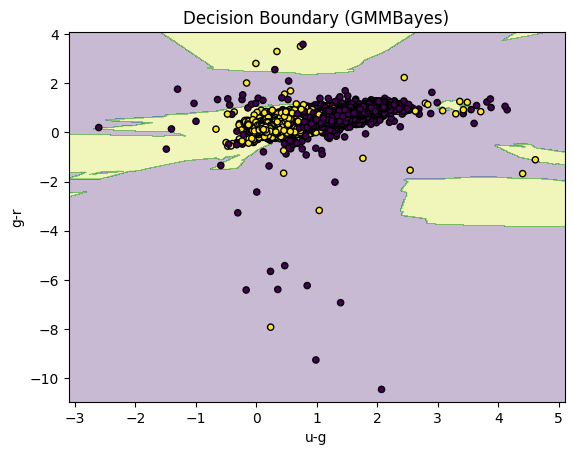

In [35]:
def plot_decision_boundaries(X, y, model, labels):
    h = .02  # step size in meshgrid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20, cmap='viridis')
    plt.xlabel(labels[0])
    plt.ylabel(labels[1])

# u-g and g-r
best_two = [0,1]
pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=best_k))
    ])
model_2d =pipe.fit(X_train[:,best_two], y_train)
plot_decision_boundaries(X_train[:,best_two], y_train, model_2d, labels=['u-g', 'g-r'])
plt.title("Decision Boundary (GMMBayes)")
plt.show()